# Learning Word2Vec Word Representations using BlazingText (V3 - sagemaker-core)


---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

---


Word2Vec is a popular algorithm used for generating dense vector representations of words in large corpora using unsupervised learning. The resulting vectors have been shown to capture semantic relationships between the corresponding words and are used extensively for many downstream natural language processing (NLP) tasks like sentiment analysis, named entity recognition and machine translation.  

> **SageMaker Python SDK v3 note:** This notebook has been migrated to the SageMaker Python SDK **v3** using the `sagemaker-core` resource-class APIs (`TrainingJob`, `Model`, `EndpointConfig`, `Endpoint`) and `sagemaker.core.image_uris`. It no longer uses the V2 `Estimator`/`Predictor` classes. Install with `pip install sagemaker` (v3) or `pip install sagemaker-core`. The BlazingText data format (plain text, one sentence per line) and all hyperparameters are unchanged from the original V2 notebook.


SageMaker BlazingText which provides efficient implementations of Word2Vec on

- single CPU instance
- single instance with multiple GPUs - P2 or P3 instances
- multiple CPU instances (Distributed training)

In this notebook, we demonstrate how BlazingText can be used for distributed training of word2vec using multiple CPU instances.

## Setup

Let's start by specifying:
- The S3 buckets and prefixes that you want to use for saving model data and where training data is located. These should be within the same region as the Notebook Instance, training, and hosting. If you don't specify a bucket, SageMaker SDK will create a default bucket following a pre-defined naming convention in the same region. 
- The IAM role ARN used to give SageMaker access to your data. It can be fetched using the **get_execution_role** method from sagemaker python SDK.

In [1]:
# [papermill-run] pip install disabled for execution copy


In [2]:
from sagemaker.core.helper.session_helper import Session, get_execution_role
import boto3
import json

sess = Session()

role = "arn:aws:iam::729646638167:role/SageMakerRole"  # [papermill-run] explicit role
print(
    role
)  # This is the role that SageMaker would use to leverage AWS resources (S3, CloudWatch) on your behalf

region = "us-west-1"

output_bucket = sess.default_bucket()  # Replace with your own bucket name if needed
print(output_bucket)
output_prefix = "sagemaker/DEMO-blazingtext-text8"  # Replace with the prefix under which you want to store the data if needed
default_bucket_prefix = sess.default_bucket_prefix

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    output_prefix = f"{default_bucket_prefix}/{output_prefix}"

data_bucket = (
    f"sagemaker-example-files-prod-{region}"  # Replace with the bucket where your data is located
)
data_prefix = "datasets/text/text8/text8"

[07/09/26 13:50:09] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=10362471;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=10362472;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


arn:aws:iam::729646638167:role/SageMakerRole


sagemaker-us-west-1-729646638167


### Data Ingestion

BlazingText expects a single preprocessed text file with space separated tokens and each line of the file should contain a single sentence. In this example, let us train the vectors on [text8](http://mattmahoney.net/dc/textdata.html) dataset (100 MB), which is a small (already preprocessed) version of Wikipedia dump. Data is already downloaded from [matt mahoney's website](http://mattmahoney.net/dc/text8.zip), uncompressed and stored in `data_bucket`. 

In [3]:
s3_client = boto3.client("s3")
s3_client.download_file(data_bucket, data_prefix, "text8")
s3_client.upload_file("text8", output_bucket, output_prefix + "/train")

s3_train_data = f"s3://{output_bucket}/{output_prefix}/train"

[07/09/26 13:50:11] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=10362477;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=10362478;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Next we need to setup an output location at S3, where the model artifact will be dumped. These artifacts are also the output of the algorithm's training job.

In [4]:
s3_output_location = f"s3://{output_bucket}/{output_prefix}/output"

## Training Setup
Now that we are done with all the setup that is needed, we are ready to train our word vectors. In V3 we use the `sagemaker-core` `TrainingJob` resource class to launch the training job. First, we resolve the BlazingText built-in algorithm container image for our region.

In [5]:
from sagemaker.core import image_uris

container = image_uris.retrieve("blazingtext", region)
print(f"Using SageMaker BlazingText container: {container} ({region})")

[07/09/26 13:50:19] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=10362483;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=10362484;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

                    INFO     Same images used for training and inference. Defaulting to image     ]8;id=10362491;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=10362492;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#398\398]8;;\
                             scope: inference.                                                                     

                    INFO     Ignoring unnecessary instance type: None.                            ]8;id=10362498;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=10362499;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#535\535]8;;\

Using SageMaker BlazingText container: 632365934929.dkr.ecr.us-west-1.amazonaws.com/blazingtext:1 (us-west-1)


## Training the BlazingText model for generating word vectors

Similar to the original implementation of [Word2Vec](https://arxiv.org/pdf/1301.3781.pdf), SageMaker BlazingText provides an efficient implementation of the continuous bag-of-words (CBOW) and skip-gram architectures using Negative Sampling, on CPUs and additionally on GPU[s]. The GPU implementation uses highly optimized CUDA kernels. To learn more, please refer to [*BlazingText: Scaling and Accelerating Word2Vec using Multiple GPUs*](https://dl.acm.org/citation.cfm?doid=3146347.3146354). BlazingText also supports learning of subword embeddings with CBOW and skip-gram modes. This enables BlazingText to generate vectors for out-of-vocabulary (OOV) words, as demonstrated in this [notebook](https://github.com/awslabs/amazon-sagemaker-examples/blob/master/introduction_to_amazon_algorithms/blazingtext_word2vec_subwords_text8/blazingtext_word2vec_subwords_text8.ipynb).




Besides skip-gram and CBOW, SageMaker BlazingText also supports the "Batch Skipgram" mode, which uses efficient mini-batching and matrix-matrix operations ([BLAS Level 3 routines](https://software.intel.com/en-us/mkl-developer-reference-fortran-blas-level-3-routines)). This mode enables distributed word2vec training across multiple CPU nodes, allowing almost linear scale up of word2vec computation to process hundreds of millions of words per second. Please refer to [*Parallelizing Word2Vec in Shared and Distributed Memory*](https://arxiv.org/pdf/1604.04661.pdf) to learn more.

BlazingText also supports a *supervised* mode for text classification. It extends the FastText text classifier to leverage GPU acceleration using custom CUDA kernels. The model can be trained on more than a billion words in a couple of minutes using a multi-core CPU or a GPU, while achieving performance on par with the state-of-the-art deep learning text classification algorithms. For more information, please refer to [algorithm documentation](https://docs.aws.amazon.com/sagemaker/latest/dg/blazingtext.html) or [the text classification notebook](https://github.com/awslabs/amazon-sagemaker-examples/blob/master/introduction_to_amazon_algorithms/blazingtext_text_classification_dbpedia/blazingtext_text_classification_dbpedia.ipynb).

To summarize, the following modes are supported by BlazingText on different types instances:

|          Modes         	| cbow (supports subwords training) 	| skipgram (supports subwords training) 	| batch_skipgram 	| supervised |
|:----------------------:	|:----:	|:--------:	|:--------------:	| :--------------:	|
|   Single CPU instance  	|   ✔  	|     ✔    	|        ✔       	|  ✔  |
|   Single GPU instance  	|   ✔  	|     ✔    	|                	|  ✔ (Instance with 1 GPU only)  |
| Multiple CPU instances 	|      	|          	|        ✔       	|     | |

Now, let's define the resource configuration and hyperparameters to train word vectors on *text8* dataset, using "batch_skipgram" mode on two c4.2xlarge instances.


Please refer to [algorithm documentation](https://docs.aws.amazon.com/sagemaker/latest/dg/blazingtext_hyperparameters.html) for the complete list of hyperparameters. Note that with the `sagemaker-core` `TrainingJob` API, hyperparameter values are passed as strings.

In [6]:
hyperparameters = {
    "mode": "batch_skipgram",
    "epochs": "5",
    "min_count": "5",
    "sampling_threshold": "0.0001",
    "learning_rate": "0.05",
    "window_size": "5",
    "vector_dim": "100",
    "negative_samples": "5",
    "batch_size": "11",  # = (2*window_size + 1) (Preferred. Used only if mode is batch_skipgram)
    "evaluation": "True",  # Perform similarity evaluation on WS-353 dataset at the end of training
    "subwords": "False",  # Subword embedding learning is not supported by batch_skipgram
}

We have our hyperparameters, and we point the `train` data channel at the plain-text training data in S3. The only remaining thing to do is to launch the training job. The following cell creates a `TrainingJob` using the `sagemaker-core` resource class and waits for it to complete. Training the algorithm involves a few steps. Firstly, the instances that we requested are provisioned and set up with the appropriate libraries. Then, the data from our channel is downloaded onto the instances. Once this is done, the training job begins. The data logs will also print out `Spearman's Rho` on some pre-selected validation datasets after the training job has executed. This metric is a proxy for the quality of the algorithm.

Once the job has finished a "Completed" status will be printed. The trained model can be found in the S3 bucket that was setup as `output_path`.

In [7]:
%%time
from time import gmtime, strftime
from sagemaker.core.resources import TrainingJob
from sagemaker.core.shapes import (
    AlgorithmSpecification,
    Channel,
    DataSource,
    S3DataSource,
    ResourceConfig,
    StoppingCondition,
    OutputDataConfig,
)

training_job_name = f"blazingtext-text8-{strftime('%Y-%m-%d-%H-%M-%S', gmtime())}"

training_job = TrainingJob.create(
    training_job_name=training_job_name,
    hyper_parameters=hyperparameters,
    algorithm_specification=AlgorithmSpecification(
        training_image=container,
        training_input_mode="File",
    ),
    role_arn=role,
    input_data_config=[
        Channel(
            channel_name="train",
            data_source=DataSource(
                s3_data_source=S3DataSource(
                    s3_data_type="S3Prefix",
                    s3_uri=s3_train_data,
                    s3_data_distribution_type="FullyReplicated",
                )
            ),
            content_type="text/plain",
        ),
    ],
    output_data_config=OutputDataConfig(s3_output_path=s3_output_location),
    resource_config=ResourceConfig(
        instance_type="ml.c4.2xlarge",
        instance_count=2,
        volume_size_in_gb=5,
    ),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=360000),
)

training_job.wait(logs=True)
print(training_job.training_job_status)

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


                    INFO     Creating training_job resource.                                     ]8;id=10362506;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10362507;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31123\31123]8;;\

                    WARNING  No region provided. Using default region.                                 ]8;id=10362514;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=10362515;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#361\361]8;;\

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=10362521;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=10362522;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

...

                    INFO     blazingtext-text8-2026-07-09-20-50-19/algo-1-1783630256:            ]8;id=10362864;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10362865;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             }                                                                                     

                    INFO     blazingtext-text8-2026-07-09-20-50-19/algo-1-1783630256:            ]8;id=10362870;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10362871;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             [07/09/2026 20:52:19 INFO 140316268734272] #mean_rho:                                 
                             0.6981010552415795                                                                    

[07/09/26 13:52:30] INFO     blazingtext-text8-2026-07-09-20-50-19/algo-2-1783630257:            ]8;id=10362876;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10362877;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             [07/09/2026 20:52:22 INFO 140544258209600] Master host is not                         
                             alive. Training might have finished. Shutting down.... Check the                      
                             logs for algo-1 machine.                                                              

[07/09/26 13:52:46] INFO     Final Resource Status: Completed                                    ]8;id=10362883;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10362884;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31475\31475]8;;\

Completed
CPU times: user 1.71 s, sys: 470 ms, total: 2.18 s
Wall time: 2min 26s


## Hosting / Inference
Once the training is done, we can deploy the trained model as an Amazon SageMaker real-time hosted endpoint. This will allow us to make predictions (or inference) from the model. Note that we don't have to host on the same type of instance that we used to train. Because instance endpoints will be up and running for long, it's advisable to choose a cheaper instance for inference.

In V3 we build the hosted endpoint from the trained model artifacts using the `sagemaker-core` `Model`, `EndpointConfig`, and `Endpoint` resource classes.

In [8]:
%%time
from sagemaker.core.resources import Model, EndpointConfig, Endpoint
from sagemaker.core.shapes import ContainerDefinition, ProductionVariant

suffix = strftime("%Y-%m-%d-%H-%M-%S", gmtime())
model_name = f"blazingtext-text8-{suffix}-model"
endpoint_config_name = f"blazingtext-text8-{suffix}-config"
endpoint_name = f"blazingtext-text8-{suffix}"

# Fetch the trained model artifacts from the training job.
model_data = TrainingJob.get(training_job_name).model_artifacts.s3_model_artifacts

bt_model = Model.create(
    model_name=model_name,
    primary_container=ContainerDefinition(
        image=container,
        model_data_url=model_data,
    ),
    execution_role_arn=role,
)

endpoint_config = EndpointConfig.create(
    endpoint_config_name=endpoint_config_name,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=model_name,
            instance_type="ml.m4.xlarge",
            initial_instance_count=1,
            initial_variant_weight=1,
        )
    ],
)

bt_endpoint = Endpoint.create(
    endpoint_name=endpoint_name,
    endpoint_config_name=endpoint_config_name,
)
bt_endpoint.wait_for_status("InService")

                    INFO     Creating model resource.                                            ]8;id=10366312;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10366313;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

                    INFO     Creating endpoint_config resource.                                  ]8;id=10366319;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10366320;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

[07/09/26 13:52:48] INFO     Creating endpoint resource.                                         ]8;id=10366326;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10366327;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/09/26 13:55:32] INFO     Final Resource Status: InService                                    ]8;id=10366333;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10366334;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

CPU times: user 2.22 s, sys: 466 ms, total: 2.69 s
Wall time: 2min 45s


### Getting vector representations for words

#### Use JSON format for inference
The payload should contain a list of words with the key as "**instances**". BlazingText supports content-type `application/json`.

In [9]:
words = ["awesome", "blazing"]

payload = {"instances": words}

response = bt_endpoint.invoke(
    body=json.dumps(payload).encode("utf-8"),
    content_type="application/json",
    accept="application/json",
).body.read()

vecs = json.loads(response)
print(vecs)

[{'vector': [0.0619293674826622, 0.15042182803153992, -0.13037341833114624, -0.1436460018157959, -0.015526901930570602, 0.10502376407384872, -0.06107712537050247, 0.004518311005085707, -0.1570553332567215, 0.20052188634872437, -0.2600278854370117, -0.00544829573482275, 0.22804561257362366, -0.05614541098475456, 0.21430815756320953, -0.010102440603077412, -0.03284416347742081, 0.07901185750961304, 0.14205989241600037, -0.02287726290524006, -0.01826348528265953, 0.025474123656749725, -0.12297943234443665, -0.03685951977968216, -0.03176230564713478, -0.010839717462658882, -0.0330265611410141, 0.11267027258872986, 0.03459402918815613, 0.21542078256607056, -0.04269087314605713, 0.10704699903726578, 0.05329057574272156, -0.12289564311504364, -0.17675700783729553, 0.09391996264457703, -0.0030947327613830566, 0.00045176479034125805, -0.24337542057037354, 0.15166039764881134, 0.0851779654622078, -0.17632369697093964, -0.09523561596870422, -0.07485884428024292, 0.3014832139015198, -0.14776802062

As expected, we get an n-dimensional vector (where n is vector_dim as specified in hyperparameters) for each of the words. If the word is not there in the training dataset, the model will return a vector of zeros.

### Evaluation

Let us now download the word vectors learned by our model and visualize them using a [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) plot.

In [10]:
s3 = boto3.resource("s3")

# model_data is the full s3://bucket/key URI of the trained model artifacts.
model_bucket = model_data.split("/")[2]
key = "/".join(model_data.split("/")[3:])
s3.Bucket(model_bucket).download_file(key, "model.tar.gz")

Uncompress `model.tar.gz` to get `vectors.txt`

In [11]:
!tar -xvzf model.tar.gz

x eval.json
x vectors.txt


x vectors.bin

If you set "evaluation" as "true" in the hyperparameters, then "eval.json" will be there in the model artifacts.

The quality of trained model is evaluated on word similarity task. We use [WS-353](http://alfonseca.org/eng/research/wordsim353.html), which is one of the most popular test datasets used for this purpose. It contains word pairs together with human-assigned similarity judgments.

The word representations are evaluated by ranking the pairs according to their cosine similarities, and measuring the Spearmans rank correlation coefficient with the human judgments.

Let's look at the evaluation scores which are there in eval.json. For embeddings trained on the text8 dataset, scores above 0.65 are pretty good.

In [12]:
!cat eval.json

{
    "EN-WS-353-ALL.txt": {
        "not_found": 2,
        "spearmans_rho": 0.6996959271631144,
        "total_pairs": 353
    },
    "EN-WS-353-REL.txt": {
        "not_found": 1,
        "spearmans_rho": 0.66736965271936,
        "total_pairs": 252
    },
    "EN-WS-353-SIM.txt": {
        "not_found": 1,
        "spearmans_rho": 0.7272375858422641,
        "total_pairs": 203
    },
    "mean_rho": 0.6981010552415795
}

Now, let us do a 2D visualization of the word vectors

In [13]:
import numpy as np
from sklearn.preprocessing import normalize

# Read the 400 most frequent word vectors. The vectors in the file are in descending order of frequency.
num_points = 400

first_line = True
index_to_word = []
with open("vectors.txt", "r") as f:
    for line_num, line in enumerate(f):
        if first_line:
            dim = int(line.strip().split()[1])
            word_vecs = np.zeros((num_points, dim), dtype=float)
            first_line = False
            continue
        line = line.strip()
        word = line.split()[0]
        vec = word_vecs[line_num - 1]
        for index, vec_val in enumerate(line.split()[1:]):
            vec[index] = float(vec_val)
        index_to_word.append(word)
        if line_num >= num_points:
            break
word_vecs = normalize(word_vecs, copy=False, return_norm=False)

In [14]:
from sklearn.manifold import TSNE

tsne = TSNE(perplexity=40, n_components=2, init="pca", max_iter=10000)
two_d_embeddings = tsne.fit_transform(word_vecs[:num_points])
labels = index_to_word[:num_points]

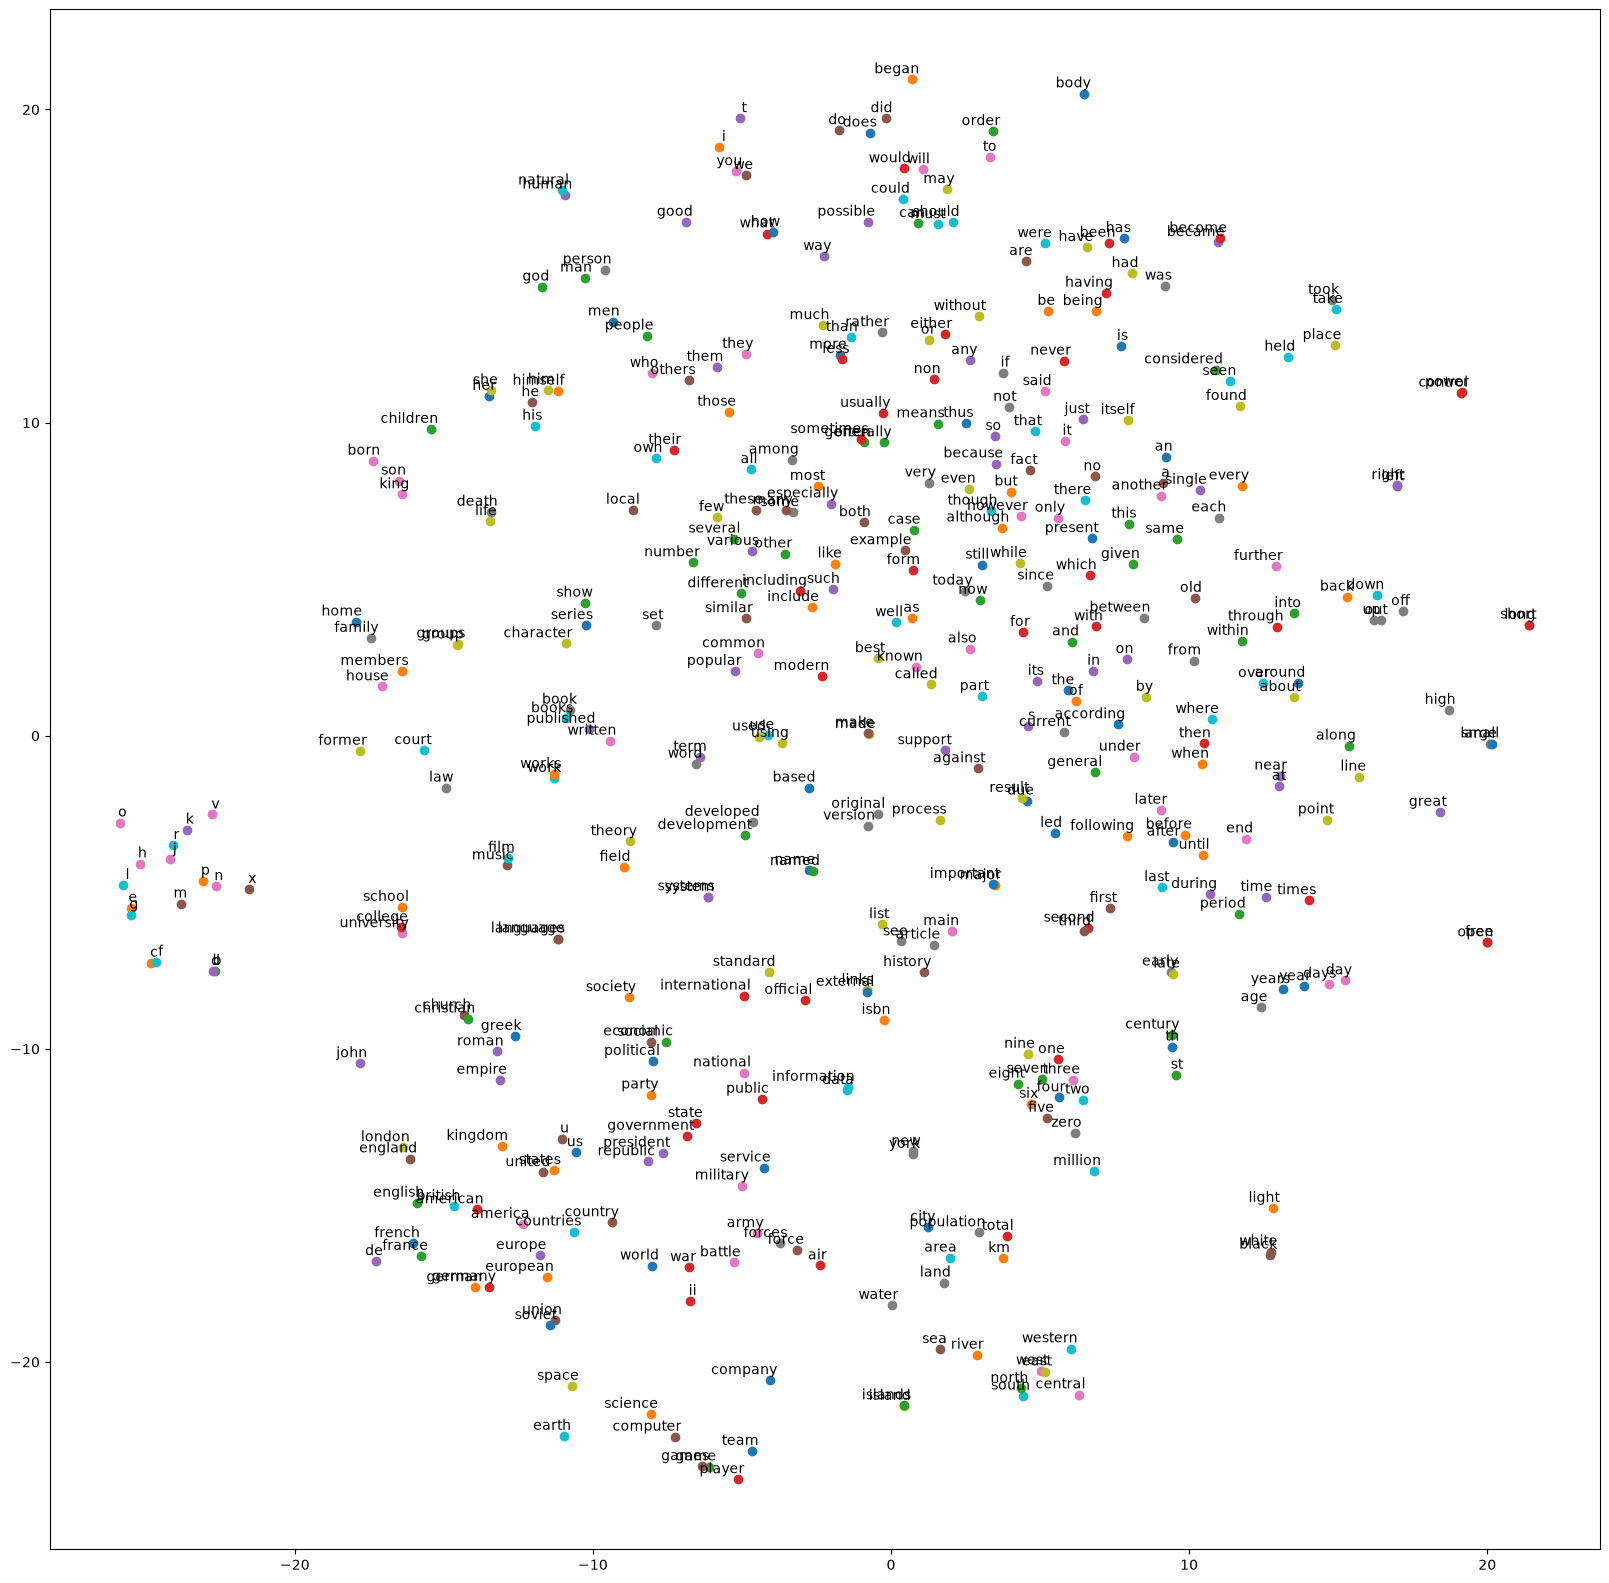

In [15]:
from matplotlib import pylab

%matplotlib inline


def plot(embeddings, labels):
    pylab.figure(figsize=(20, 20))
    for i, label in enumerate(labels):
        x, y = embeddings[i, :]
        pylab.scatter(x, y)
        pylab.annotate(
            label, xy=(x, y), xytext=(5, 2), textcoords="offset points", ha="right", va="bottom"
        )
    pylab.show()


plot(two_d_embeddings, labels)

Running the code above might generate a plot like the one below. t-SNE and Word2Vec are stochastic, so although when you run the code the plot won’t look exactly like this, you can still see clusters of similar words such as below where 'british', 'american', 'french', 'english' are near the bottom-left, and 'military', 'army' and 'forces' are all together near the bottom.

![tsne plot of embeddings](./tsne.png)

### Stop / Close the Endpoint (Optional)
Finally, we should delete the endpoint before we close the notebook.

In [16]:
bt_endpoint.delete()
endpoint_config.delete()
bt_model.delete()

[07/09/26 13:55:44] INFO     Deleting Endpoint - blazingtext-text8-2026-07-09-20-52-47           ]8;id=10370174;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10370175;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

                    INFO     Deleting EndpointConfig -                                           ]8;id=10370181;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10370182;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\
                             blazingtext-text8-2026-07-09-20-52-47-config                                          

                    INFO     Deleting Model - blazingtext-text8-2026-07-09-20-52-47-model        ]8;id=10370188;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=10370189;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/build_and_train_models|sm-introduction_to_blazingtext_word2vec_text8|sm-introduction_to_blazingtext_word2vec_text8.ipynb)
